In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import scipy.stats 
import pandas as pd
from sklearn.linear_model import LinearRegression

np.random.seed(1)

import warnings
warnings.filterwarnings('ignore')


## Data

We consider the [Kings County housing dataset](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction). It includes homes sold between May 2014 and May 2015.

Specifically, we focuse on the Rainier Valley zipcode.

In [2]:
# Load the dataset
house = pd.read_csv("data/rainier_valley_house.csv")

In [3]:
house.columns

Index(['Unnamed: 0', 'id', 'date', 'price', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [4]:
# We will consider this subset of features
features = ["floors", "grade", "condition", "view", "sqft_living",
            "sqft_lot", "sqft_basement", "yr_built", "yr_renovated",
            "bedrooms", "bathrooms", "lat", "long"]

house = house[house['price'] < 1e6]

Y = house['price'] / 1000
X = house[features]

## Standardize the features
scaler = StandardScaler()
X_stan = scaler.fit_transform(X)

## Linear regression    

### Formula

We compute the regression coefficients using the formula:

$$\widehat{\beta} = (X^\top X)^{-1}X^\top y$$

In [5]:
## linear regression
X_stan1 = np.hstack([np.ones((X_stan.shape[0], 1)), X_stan])
X_train, X_test, Y_train, Y_test = train_test_split(X_stan1, Y, test_size=100, train_size=400, random_state=2)

betahat = np.linalg.inv(X_train.T @ X_train) @ (X_train.T @ Y_train)
Y_pred = X_test @ betahat

test_error = np.sqrt(((Y_test - Y_pred) ** 2).mean())
baseline_error = np.sqrt(((Y_test - Y_train.mean()) ** 2).mean())

## print coefficients
print("Coefficients:")
features = ['Intercept'] + list(X.columns)
for i, f in enumerate(features):
    print(f"{f}: {betahat[i]:.3f}")


print(f"Test RMSE of linear regression: {test_error:.3f}   Baseline RMSE: {baseline_error:.3f}")

R2 = 1 - test_error**2 / baseline_error**2
print(f"Test R-squared of linear regression: {R2:.3f}")


Coefficients:
Intercept: 397.667
floors: 7.706
grade: 44.060
condition: 17.140
view: 27.275
sqft_living: 72.711
sqft_lot: 12.589
sqft_basement: -12.538
yr_built: -13.716
yr_renovated: 2.193
bedrooms: -19.933
bathrooms: 10.003
lat: 70.999
long: 29.816
Test RMSE of linear regression: 84.774   Baseline RMSE: 151.875
Test R-squared of linear regression: 0.688


### Using Scikit-Learn

We can also use scikit-learn (sklearn) to run linear regression for us:

In [6]:
# remove the intercept column - sklearn adds it by default
X_train = X_train[:, 1:]
X_test = X_test[:, 1:]

linreg = LinearRegression()
linreg.fit(X_train, Y_train)
Y_pred = linreg.predict(X_test)

test_error = np.sqrt(((Y_test - Y_pred) ** 2).mean())
baseline_error = np.sqrt(((Y_test - Y_train.mean()) ** 2).mean())

print(f"Test RMSE of linear regression: {test_error:.3f}   Baseline RMSE: {baseline_error:.3f}")

R2 = 1 - test_error**2 / baseline_error**2
print(f"Test R-squared of linear regression: {R2:.3f}")

Test RMSE of linear regression: 84.774   Baseline RMSE: 151.875
Test R-squared of linear regression: 0.688


In [7]:
linreg.intercept_

np.float64(397.6669185000979)

In [8]:
## print coefficients
print("Coefficients:")
features = X.columns

print(f"Intercept: {linreg.intercept_:.3f}")

for i, f in enumerate(features):
    print(f"{f}: {linreg.coef_[i]:.3f}")


Coefficients:
Intercept: 397.667
floors: 7.706
grade: 44.060
condition: 17.140
view: 27.275
sqft_living: 72.711
sqft_lot: 12.589
sqft_basement: -12.538
yr_built: -13.716
yr_renovated: 2.193
bedrooms: -19.933
bathrooms: 10.003
lat: 70.999
long: 29.816


### Inference

#### t-tests for coefficients

In [9]:
# Compute confidence intervals for coefficients using stats
X_train1 = np.hstack([np.ones((X_train.shape[0], 1)), X_train])

# Get predictions and residuals
Y_pred_train = linreg.predict(X_train)
residuals = Y_train - Y_pred_train

# Degrees of freedom
n = X_train.shape[0]
p = X_train.shape[1]
df = n - p - 1

# Estimate sigma squared
sigma2 = np.sum(residuals**2) / df

# Covariance matrix
cov_beta = sigma2 * np.linalg.inv(X_train1.T @ X_train1)

# Standard errors
se = np.sqrt(np.diag(cov_beta))

# Beta coefficients (including intercept)
beta = np.concatenate([[linreg.intercept_], linreg.coef_])

# t-value for 95% CI
t_val = scipy.stats.t.ppf(0.975, df)

# Confidence intervals
ci_lower = beta - t_val * se
ci_upper = beta + t_val * se

# Print results
features_list = ['Intercept'] + list(features)
print("95% Confidence Intervals for Coefficients:")
for i, f in enumerate(features_list):
    print(f"{f}: ({ci_lower[i]:.3f}, {ci_upper[i]:.3f})")

95% Confidence Intervals for Coefficients:
Intercept: (389.030, 406.304)
floors: (-5.826, 21.238)
grade: (30.209, 57.911)
condition: (7.723, 26.557)
view: (17.446, 37.103)
sqft_living: (51.261, 94.161)
sqft_lot: (2.133, 23.046)
sqft_basement: (-27.696, 2.620)
yr_built: (-26.742, -0.690)
yr_renovated: (-6.720, 11.106)
bedrooms: (-32.697, -7.169)
bathrooms: (-5.899, 25.904)
lat: (60.735, 81.264)
long: (19.434, 40.198)


#### Using the bootstrap

In [10]:
Y_train = Y_train.to_numpy()
n_train = X_train.shape[0]

beta = np.zeros((1+X_train.shape[1]))
beta[0] = linreg.intercept_
beta[1:] = linreg.coef_

n_boot = 1000

bootstrap_inds = [np.random.choice(range(1, n_train), n_train, replace=True) for _ in range(n_boot)]

boot_bhats = np.zeros((n_boot, 1+X_train.shape[1]))
for b in range(n_boot):
    X_boot = X_train[bootstrap_inds[b]]
    Y_boot = Y_train[bootstrap_inds[b]]
    linreg = LinearRegression()
    linreg.fit(X_boot, Y_boot)
    boot_bhats[b, 0] = linreg.intercept_
    boot_bhats[b, 1:] = linreg.coef_

![](fig/boot_linreg.gif)

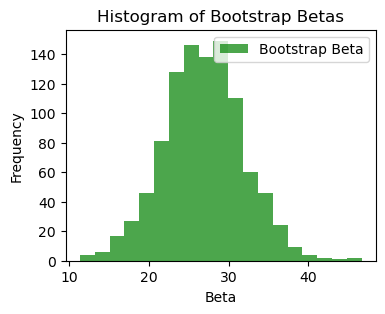

In [11]:
bins_beta = np.linspace(boot_bhats[:, 4].min(), boot_bhats[:, 4].max(), 20)

plt.figure(figsize=(4,3))
plt.hist(boot_bhats[:, 4], bins=bins_beta, alpha=0.7, color='green', label='Bootstrap Beta')
plt.title('Histogram of Bootstrap Betas')
plt.xlabel('Beta')
plt.ylabel('Frequency')
plt.legend()

In [12]:
beta_sds = np.std(boot_bhats, axis=0)

In [13]:
# confidence interval
lower_quantiles = beta - 2 * beta_sds
upper_quantiles = beta + 2 * beta_sds

# Print results
features_list = ['Intercept'] + list(features)
print("95% Bootstrap Confidence Intervals for Coefficients:")
for i, f in enumerate(features_list):
    print(f"{f}: ({lower_quantiles[i]:.3f}, {upper_quantiles[i]:.3f})")

95% Bootstrap Confidence Intervals for Coefficients:
Intercept: (388.878, 406.456)
floors: (-6.717, 22.129)
grade: (27.224, 60.895)
condition: (7.662, 26.619)
view: (17.276, 37.273)
sqft_living: (48.540, 96.882)
sqft_lot: (-1.782, 26.961)
sqft_basement: (-29.503, 4.427)
yr_built: (-29.000, 1.567)
yr_renovated: (-7.993, 12.379)
bedrooms: (-35.586, -4.280)
bathrooms: (-7.101, 27.106)
lat: (60.028, 81.971)
long: (19.281, 40.350)
